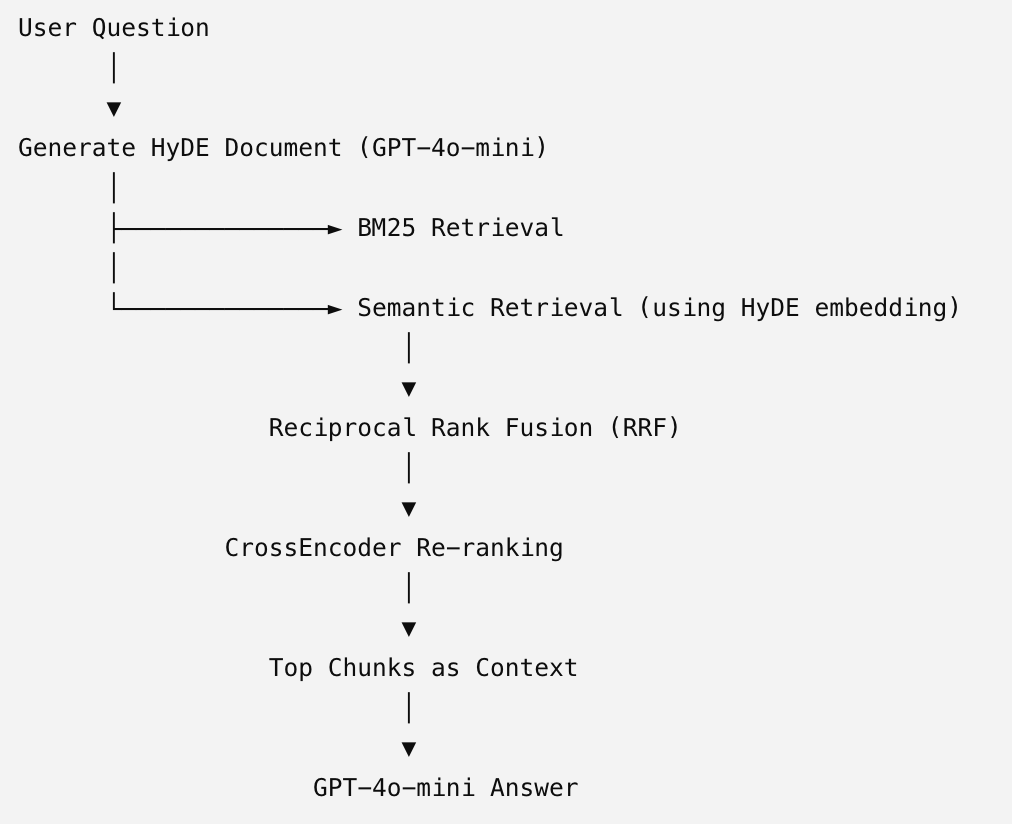

In [ ]:
!pip install -q pymupdf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.0/25.0 MB 70.1 MB/s eta 0:00:00


In [ ]:
# Install dependencies
!pip -q install openai rank_bm25 sentence-transformers python-dotenv


In [ ]:
import fitz
import numpy as np

from google.colab import files, userdata
from rank_bm25 import BM25Okapi
from sentence_transformers import SentenceTransformer, CrossEncoder
from openai import OpenAI

# =====================================================
# OpenAI Client
# =====================================================

client = OpenAI(api_key=userdata.get("OPENAI_API_KEY"))

# =====================================================
# Upload PDF
# =====================================================

uploaded = files.upload()
pdf_path = list(uploaded.keys())[0]

# =====================================================
# Read PDF and Create Chunks
# =====================================================

CHUNK_SIZE = 500

chunks = []
chunk_id = 1

doc = fitz.open(pdf_path)

for page_number, page in enumerate(doc):

    page_text = page.get_text()

    start = 0

    while start < len(page_text):

        text = page_text[start:start + CHUNK_SIZE]

        chunks.append({
            "chunk_id": chunk_id,
            "source": pdf_path,
            "page": page_number + 1,
            "text": text
        })

        chunk_id += 1
        start += CHUNK_SIZE

doc.close()

print(f"\nTotal Chunks: {len(chunks)}")

# =====================================================
# Metadata Filter
# =====================================================

def metadata_filter(chunk_list, filters=None):

    if filters is None:
        return chunk_list

    filtered = []

    for c in chunk_list:

        ok = True

        for k, v in filters.items():

            if c.get(k) != v:
                ok = False
                break

        if ok:
            filtered.append(c)

    return filtered

# =====================================================
# Build BM25
# =====================================================

def build_bm25(chunk_list):

    tokenized = [
        x["text"].lower().split()
        for x in chunk_list
    ]

    return BM25Okapi(tokenized)

# =====================================================
# Embedding Model
# =====================================================

embedder = SentenceTransformer(
    "sentence-transformers/all-MiniLM-L6-v2"
)

# =====================================================
# Cross Encoder
# =====================================================

cross_encoder = CrossEncoder(
    "cross-encoder/ms-marco-MiniLM-L-6-v2"
)

# =====================================================
# HyDE
# =====================================================

def generate_hyde(query):

    response = client.chat.completions.create(

        model="gpt-4o-mini",

        temperature=0,

        messages=[
            {
                "role": "system",
                "content":
                "Write a short factual paragraph that would answer the question."
            },
            {
                "role": "user",
                "content": query
            }
        ]
    )

    return response.choices[0].message.content

# =====================================================
# RRF
# =====================================================

def reciprocal_rank_fusion(rankings, k=60):

    scores = {}

    for ranking in rankings:

        for rank, idx in enumerate(ranking):

            scores[idx] = scores.get(idx, 0) + 1 / (k + rank + 1)

    return sorted(
        scores.items(),
        key=lambda x: x[1],
        reverse=True
    )

# =====================================================
# Retrieval
# =====================================================

def retrieve(
    query,
    filters=None,
    bm25_top_k=5,
    semantic_top_k=5,
    final_top_k=5
):

    filtered_chunks = metadata_filter(chunks, filters)

    bm25 = build_bm25(filtered_chunks)

    embeddings = embedder.encode(
        [x["text"] for x in filtered_chunks],
        convert_to_numpy=True,
        normalize_embeddings=True
    )

    # -------------------------
    # BM25
    # -------------------------

    bm25_scores = bm25.get_scores(
        query.lower().split()
    )

    bm25_order = np.argsort(bm25_scores)[::-1]

    bm25_order = bm25_order[:bm25_top_k]

    print("\n========================")
    print("BM25 RESULTS")
    print("========================")

    for rank, idx in enumerate(bm25_order, 1):

        c = filtered_chunks[idx]

        print(f"\nRank {rank}")
        print("Chunk:", c["chunk_id"])
        print("Page :", c["page"])
        print(c["text"][:250])

    # -------------------------
    # HyDE
    # -------------------------

    hyde_doc = generate_hyde(query)

    print("\n========================")
    print("HyDE DOCUMENT")
    print("========================")
    print(hyde_doc)

    # -------------------------
    # Semantic Search
    # -------------------------

    query_embedding = embedder.encode(
        hyde_doc,
        convert_to_numpy=True,
        normalize_embeddings=True
    )

    similarities = embeddings @ query_embedding

    semantic_order = np.argsort(similarities)[::-1]

    semantic_order = semantic_order[:semantic_top_k]

    print("\n========================")
    print("SEMANTIC RESULTS")
    print("========================")

    for rank, idx in enumerate(semantic_order, 1):

        c = filtered_chunks[idx]

        print(f"\nRank {rank}")
        print("Chunk:", c["chunk_id"])
        print("Page :", c["page"])
        print(c["text"][:250])

    # -------------------------
    # RRF
    # -------------------------

    fused = reciprocal_rank_fusion(
        [bm25_order, semantic_order]
    )

    print("\n========================")
    print("RRF RESULTS")
    print("========================")

    candidate_indices = []

    for rank, (idx, score) in enumerate(fused, 1):

        candidate_indices.append(idx)

        c = filtered_chunks[idx]

        print(f"\nRank {rank}")
        print("RRF Score:", score)
        print("Chunk:", c["chunk_id"])
        print("Page :", c["page"])

    # -------------------------
    # CrossEncoder
    # -------------------------

    candidate_chunks = [
        filtered_chunks[i]
        for i in candidate_indices
    ]

    pairs = [
        [query, x["text"]]
        for x in candidate_chunks
    ]

    scores = cross_encoder.predict(pairs)

    reranked = sorted(
        zip(candidate_chunks, scores),
        key=lambda x: x[1],
        reverse=True
    )

    final_chunks = [
        x[0]
        for x in reranked[:final_top_k]
    ]

    print("\n========================")
    print("FINAL RERANKED")
    print("========================")

    for i, c in enumerate(final_chunks, 1):

        print(f"\nRank {i}")
        print("Chunk:", c["chunk_id"])
        print("Page :", c["page"])
        print(c["text"][:250])

    return final_chunks

# =====================================================
# Ask Question
# =====================================================

question = input("\nEnter your question: ")

# Example metadata filter:
#
# filters = {"page": 2}
#
# or
#
# filters = {"source": pdf_path}
#
# or
#
# filters = None

filters = None

retrieved = retrieve(
    question,
    filters=filters
)

context = "\n\n".join(
    [
        x["text"]
        for x in retrieved
    ]
)

response = client.chat.completions.create(

    model="gpt-4o-mini",

    temperature=0,

    messages=[
        {
            "role": "system",
            "content":
            "Answer only using the supplied context. "
            "If the answer is unavailable, say you don't know."
        },
        {
            "role": "user",
            "content":
            f"Context:\n{context}\n\nQuestion:\n{question}"
        }
    ]
)

print("\n========================")
print("FINAL ANSWER")
print("========================")
print(response.choices[0].message.content)

Saving The Brain Behind AI.pdf to The Brain Behind AI.pdf

Total Chunks: 111


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/1.33k [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]


Enter your question: What is All About

BM25 RESULTS

Rank 1
Chunk: 99
Page : 14
 *know* what a bat is, or what money is. It
has never held a ball in its hand, never felt the weight of a dollar. So what’s happening? The
transformer isn’t *thinking* — at least, not in the way we do. But it’s *simulating thought* with such
fidelity

Rank 2
Chunk: 92
Page : 13
ust make
mistakes. It makes **authoritative mistakes**—because it speaks with the confidence of a god, even
when wrong. --- ### **V. The Path Forward: Can We Scale with Wisdom?** The scaling imperative is
real. But so is the need for **responsible in

Rank 3
Chunk: 96
Page : 14
Chapter 5
# **Chapter 5: The Next Mind — Toward Artificial General Intelligence** ### *What Transformers Tell
Us About Human Cognition and the Future of AI* > *"We are not building machines that think like us.
We are building machines that force us t

Rank 4
Chunk: 2
Page : 2
Preface
**Preface: The Brain Behind AI** Imagine standing at the edge of a vast, un